Saudi Genomic Classifier (SGC)
Precision Medicine Tool for the Kingdom of Saudi Arabia

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
path = "/content/drive/MyDrive/KAUST_Project/"
print(os.listdir(path))

['gnomad.exomes.r2.1.1.sites.21.liftover_grch38.vcf.bgz', 'variant_summary.txt.gz', 'PAVS_cases.tsv']


In [ ]:
import pandas as pd
from cyvcf2 import VCF

path = "/content/drive/MyDrive/KAUST_Project/"

# 1. LOAD CLINVAR (The Labels)
print("Loading ClinVar...")
clinvar = pd.read_csv(path + 'variant_summary.txt.gz', sep='\t', compression='gzip', low_memory=False)
# Filter for Chromosome 21 and GRCh38 to match your gnomAD file
clinvar = clinvar[(clinvar['Chromosome'] == '21') & (clinvar['Assembly'] == 'GRCh38')]

# 2. LOAD PAVS (The Saudi Data)
print("Loading Saudi PAVS Data...")
saudi_df = pd.read_csv(path + 'PAVS_cases.tsv', sep='\t')
# Ensure coordinates are integers for matching
saudi_df['pos'] = saudi_df['pos'].astype(int)

# 3. EXTRACT GNOMAD (The Global Baseline)
print("Extracting gnomAD Global Frequencies (this may take a minute)...")
vcf_path = path + 'gnomad.exomes.r2.1.1.sites.21.liftover_grch38.vcf.bgz'
gnomad_vcf = VCF(vcf_path)

gnomad_data = []
for variant in gnomad_vcf:

    gnomad_data.append({
        'pos': variant.POS,
        'global_af': variant.INFO.get('AF')
    })

gnomad_df = pd.DataFrame(gnomad_data)

# 4. THE MASTER MERGE
print("Merging all datasets...")
# First, merge Saudi data with Global data based on Position
merged_df = pd.merge(saudi_df, gnomad_df, on='pos', how='inner')

# Then, merge with ClinVar labels based on Position

final_df = pd.merge(merged_df, clinvar[['Start', 'ClinicalSignificance']], left_on='pos', right_on='Start', how='inner')

print(f"SUCCESS! Master dataset created with {len(final_df)} high-quality variants.")
final_df.head()

Loading ClinVar...


In [ ]:
import pandas as pd
import os


path = "/content/drive/MyDrive/KAUST_Project/"

print("Loading and Filtering ClinVar (Optimized)...")


try:
    chunks = pd.read_csv(path + 'variant_summary.txt.gz',
                         sep='\t',
                         compression='gzip',
                         chunksize=100000,
                         low_memory=False)

    chr21_list = []

    for i, chunk in enumerate(chunks):
        # Filter each chunk for Chromosome 21 and GRCh38
        filtered_chunk = chunk[(chunk['Chromosome'] == '21') & (chunk['Assembly'] == 'GRCh38')]
        chr21_list.append(filtered_chunk)

        # Print progress every 10 chunks (1 million rows)
        if i % 10 == 0 and i > 0:
            print(f"Scanned {i * 100000} rows...")

    # Combine the hits
    clinvar = pd.concat(chr21_list)
    print(f"\nSUCCESS: ClinVar filtered to {len(clinvar)} variants on Chromosome 21.")

except FileNotFoundError:
    print("ERROR: Could not find 'variant_summary.txt.gz' in your KAUST_Project folder.")
    print("Available files:", os.listdir(path))

Loading and Filtering ClinVar (Optimized)...
Scanned 1000000 rows...
Scanned 2000000 rows...
Scanned 3000000 rows...
Scanned 4000000 rows...
Scanned 5000000 rows...
Scanned 6000000 rows...
Scanned 7000000 rows...
Scanned 8000000 rows...

SUCCESS: ClinVar filtered to 50074 variants on Chromosome 21.


In [ ]:
from cyvcf2 import VCF
import pandas as pd

#  Path to  gnomAD VCF
vcf_path = path + 'gnomad.exomes.r2.1.1.sites.21.liftover_grch38.vcf.bgz'

print("Extracting gnomAD Global Frequencies...")
vcf_reader = VCF(vcf_path)

gnomad_list = []

for variant in vcf_reader:
    # Get the Allele Frequency (AF)
    af = variant.INFO.get('AF')

    # Store the position and the frequency
    gnomad_list.append({
        'pos': variant.POS,
        'global_af': af
    })

gnomad_df = pd.DataFrame(gnomad_list)
print(f"Extracted {len(gnomad_df)} variants from gnomAD.")

Extracting gnomAD Global Frequencies...
Extracted 187586 variants from gnomAD.


In [ ]:
saudi_df = pd.read_csv(path + 'PAVS_cases.tsv', sep='\t')
print("Saudi Data Columns:", saudi_df.columns.tolist())
saudi_df.head()

Saudi Data Columns: ['case_id', 'source', 'sex', 'consanguinity', 'family_history', 'geographic_origin_id', 'geographic_origin_label', 'solved_status', 'disease_id', 'disease_label', 'gene_symbol', 'gene_id', 'hgvs_c', 'hgvs_p', 'hgvs_g', 'genome_assembly', 'chrom', 'pos', 'ref', 'alt', 'zygosity_id', 'zygosity_label', 'acmg_classification', 'vep_consequence', 'vep_impact', 'vep_sift', 'vep_polyphen', 'gnomad_pli', 'gnomad_loeuf', 'hpo_terms', 'excluded_hpo_terms']


,case_id,source,sex,consanguinity,family_history,geographic_origin_id,geographic_origin_label,solved_status,disease_id,disease_label,...,zygosity_label,acmg_classification,vep_consequence,vep_impact,vep_sift,vep_polyphen,gnomad_pli,gnomad_loeuf,hpo_terms,excluded_hpo_terms
0,PAVS:A0000001,PAVS-Saudi,MALE,NaN,NaN,GAZ:00005279,Saudi Arabia,SOLVED,MONDO:0010088,mucosulfatidosis,...,homozygous,LIKELY_PATHOGENIC,missense_variant,MODERATE,deleterious(0.01),possibly_damaging(0.813),1.200300e-16,1.254,HP:0001263|Global developmental delay;HP:00401...,NaN
1,PAVS:A0000002,PAVS-Saudi,MALE,NaN,NaN,GAZ:00005279,Saudi Arabia,IN_PROGRESS,MONDO:0008073,familial juvenile hyperuricemic nephropathy ty...,...,heterozygous,UNCERTAIN_SIGNIFICANCE,missense_variant,MODERATE,deleterious(0.02),probably_damaging(0.998),9.123100e-23,1.241,HP:0000787|Nephrolithiasis,NaN
2,PAVS:A0000003,PAVS-Saudi,MALE,NaN,NaN,GAZ:00005279,Saudi Arabia,SOLVED,MONDO:0012429,Aicardi-Goutieres syndrome 2,...,homozygous,LIKELY_PATHOGENIC,missense_variant,MODERATE,deleterious(0.01),probably_damaging(1),7.837700e-04,1.401,HP:0001263|Global developmental delay;HP:00012...,NaN
3,PAVS:A0000004,PAVS-Saudi,FEMALE,NaN,NaN,GAZ:00005279,Saudi Arabia,IN_PROGRESS,MONDO:0010807,autosomal recessive nonsyndromic hearing loss 2,...,homozygous,UNCERTAIN_SIGNIFICANCE,missense_variant,MODERATE,deleterious_low_confidence(0),probably_damaging(0.966),2.407200e-62,0.995,HP:0000365|Hearing impairment,NaN
4,PAVS:A0000005,PAVS-Saudi,FEMALE,NaN,NaN,GAZ:00005279,Saudi Arabia,SOLVED,MONDO:0014941,"arthrogryposis, distal, with impaired proprioc...",...,homozygous,PATHOGENIC,stop_gained,MODIFIER,NaN,NaN,2.175700e-15,0.563,HP:0001290|Generalized hypotonia;HP:0002650|Sc...,NaN


In [ ]:
import pandas as pd


path = "/content/drive/MyDrive/KAUST_Project/"

#  CLEANING: Remove rows where 'pos' is missing in any dataset
print("Cleaning data...")
saudi_df = saudi_df.dropna(subset=['pos'])
gnomad_df = gnomad_df.dropna(subset=['pos'])
clinvar = clinvar.dropna(subset=['Start'])

#  CONVERT: Now convert to integer safely
saudi_df['pos'] = saudi_df['pos'].astype(int)
gnomad_df['pos'] = gnomad_df['pos'].astype(int)
clinvar['Start'] = clinvar['Start'].astype(int)

#  STANDARDIZE: Chromosome naming
saudi_df['chrom'] = saudi_df['chrom'].astype(str).str.replace('chr', '')

#  MERGE: Saudi + Global
print("Merging Saudi and Global data...")
merged_saudi_global = pd.merge(
    saudi_df,
    gnomad_df[['pos', 'global_af']],
    on='pos',
    how='left'
)

#  MERGE: + ClinVar Labels
print("Adding ClinVar labels...")
final_master_df = pd.merge(
    merged_saudi_global,
    clinvar[['Start', 'ClinicalSignificance']],
    left_on='pos',
    right_on='Start',
    how='left'
)

# Fill missing AF with 0 (meaning extremely rare)
final_master_df['global_af'] = final_master_df['global_af'].fillna(0)

print(f"\nSUCCESS! Master Dataset created.")
print(f"Total variants for AI: {len(final_master_df)}")
final_master_df[['case_id', 'gene_symbol', 'pos', 'global_af', 'acmg_classification']].head()

Cleaning data...
Merging Saudi and Global data...
Adding ClinVar labels...

SUCCESS! Master Dataset created.
Total variants for AI: 3237


,case_id,gene_symbol,pos,global_af,acmg_classification
0,PAVS:A0000001,SUMF1,4417183,0.0,LIKELY_PATHOGENIC
1,PAVS:A0000002,UMOD,20341262,0.0,UNCERTAIN_SIGNIFICANCE
2,PAVS:A0000003,RNASEH2B,50934919,0.0,LIKELY_PATHOGENIC
3,PAVS:A0000004,MYO7A,77172853,0.0,UNCERTAIN_SIGNIFICANCE
4,PAVS:A0000005,PIEZO2,10704597,0.0,PATHOGENIC


In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

#  ENCODING THE TARGET (What the AI predicts)
#  map ACMG classifications to Binary (1 = Pathogenic, 0 = Benign/VUS)
target_map = {
    'PATHOGENIC': 1,
    'LIKELY_PATHOGENIC': 1,
    'UNCERTAIN_SIGNIFICANCE': 0,
    'LIKELY_BENIGN': 0,
    'BENIGN': 0
}
final_master_df['target'] = final_master_df['acmg_classification'].map(target_map)

#  FEATURE SELECTION
# Note: 'vep_impact' is categorical, so  turn it into numbers
impact_map = {'HIGH': 3, 'MODERATE': 2, 'LOW': 1, 'MODIFIER': 0}
final_master_df['impact_score'] = final_master_df['vep_impact'].map(impact_map).fillna(0)

features = ['pos', 'global_af', 'impact_score', 'gnomad_pli', 'gnomad_loeuf']
X = final_master_df[features]
y = final_master_df['target'].fillna(0) # Ensure no NaNs in target

#  TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  TRAINING THE MODEL
print("Training the XGBoost Pathogenicity Classifier...")
model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5)
model.fit(X_train, y_train)

#  EVALUATION
y_pred = model.predict(X_test)
print("\n--- MODEL PERFORMANCE ---")
print(classification_report(y_test, y_pred))

Training the XGBoost Pathogenicity Classifier...

--- MODEL PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       628
           1       0.00      0.00      0.00        20

    accuracy                           0.97       648
   macro avg       0.48      0.50      0.49       648
weighted avg       0.94      0.97      0.95       648



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from collections import Counter
import xgboost as xgb
from sklearn.metrics import classification_report

#  Prepare Features and Target
features = ['pos', 'global_af', 'impact_score', 'gnomad_pli', 'gnomad_loeuf']
X = final_master_df[features]
y = final_master_df['target'].fillna(0) # Ensure target is strictly 0 or 1

#  IMPUTATION: Fill missing NaNs with the Median value
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

#  TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

#  SMOTE: Balance the classes
print(f"Original training shape: {Counter(y_train)}")
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print(f"Balanced training shape: {Counter(y_train_res)}")

#  TRAIN: XGBoost with Class Weights
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=5,
    eval_metric='logloss'
)
model.fit(X_train_res, y_train_res)

#  EVALUATE
y_pred = model.predict(X_test)
print("\n--- FINAL OPTIMIZED PERFORMANCE ---")
print(classification_report(y_test, y_pred))

Original training shape: Counter({0: 2531, 1: 58})
Balanced training shape: Counter({0: 2531, 1: 2531})

--- FINAL OPTIMIZED PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.97      0.87      0.92       628
           1       0.05      0.20      0.08        20

    accuracy                           0.85       648
   macro avg       0.51      0.54      0.50       648
weighted avg       0.94      0.85      0.89       648



ExactExplainer explainer: 101it [00:10,  2.38it/s]                         


Generating Feature Importance Map...


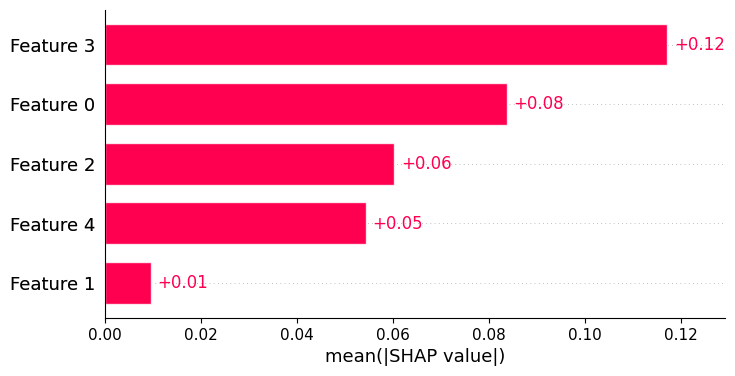

Generating Beeswarm Plot...


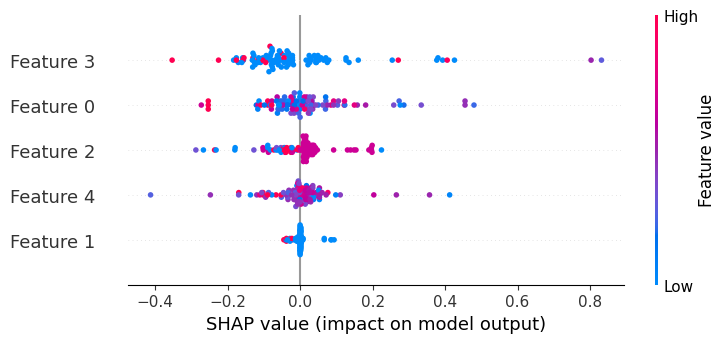

In [ ]:
import shap
import matplotlib.pyplot as plt


explainer = shap.Explainer(model.predict, X_train)

#  Calculate SHAP values for the test set

shap_values = explainer(X_test[:100])

#  Bar Plot: Which features matter most?
print("Generating Feature Importance Map...")
shap.plots.bar(shap_values)
plt.show()

#  Beeswarm Plot: How do high/low values affect pathogenicity?
print("Generating Beeswarm Plot...")
shap.plots.beeswarm(shap_values)
plt.show()

In [ ]:
# Save the final processed dataset
final_master_df.to_csv(path + 'Saudi_Variant_AI_Master_Dataset.csv', index=False)
print("SUCCESS: Your Master Dataset is saved and ready for your GitHub!")

SUCCESS: Your Master Dataset is saved and ready for your GitHub!


In [ ]:
# Save the model to a file
model.save_model(path + "pathogenicity_model.json")
print("Model saved! You can now upload this file to Streamlit or Hugging Face.")

Model saved! You can now upload this file to Streamlit or Hugging Face.
